Mini-Project: Predicting Heart Disease Using Logistic Regression


👩‍🏫 👩🏿‍🏫 What You’ll learn

    How to handle real-world healthcare data.
    Preprocessing data: Handling missing values, categorical variables, and feature scaling.
    Training a logistic regression model to predict the presence of heart disease.
    Evaluating the model’s performance using accuracy, precision, recall, and the F1 score.


💼 Tools and Libraries Required

    Python: A popular programming language for data analysis and machine learning.
    scikit-learn: Provides tools for data mining and data analysis, including logistic regression.
    pandas: For data manipulation and analysis.
    matplotlib and seaborn: For data visualization.
    Jupyter Notebook or any Python IDE.


Task

Your task is to use the Heart Disease UCI dataset to predict whether or not a patient has heart disease based on various medical attributes.

1. Data Preparation:

    Download the “Heart Disease UCI” dataset.
    Perform exploratory data analysis (EDA) to understand the dataset.
    Preprocess the data: handle missing values if any, encode categorical variables, and scale the features.

2. Model Training:

    Split the dataset into a training set and a testing set.
    Train a logistic regression model on the training set.

3. Model Evaluation:

    Evaluate the model on the testing set using accuracy, precision, recall, and F1 score.
    Use a confusion matrix to visualize the model’s performance.


Expected Deliverables

A Jupyter Notebook containing:

    The EDA and preprocessing steps.
    The code for training and evaluating the logistic regression model.
    A confusion matrix and classification report for model evaluation.
    Any visualizations that helped you understand the dataset and the model’s performance.




In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, classification_report, roc_auc_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [27]:
# "1. Data Preparation:

#     Download the “Heart Disease UCI” dataset.
#     Perform exploratory data analysis (EDA) to understand the dataset.
#     Preprocess the data: handle missing values if any, encode categorical variables, and scale the features."
df = pd.read_csv('heart_disease_uci.csv')
print(f'df shape: {df.shape}')
display(df.info())
display(df.head())
display(df.describe())


df shape: (920, 16)
<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB


None

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [28]:
# Checking values of categorical values:
for col in ['sex','dataset','cp','fbs','restecg','slope','thal']:
    display(df[col].value_counts())

sex
Male      726
Female    194
Name: count, dtype: int64

dataset
Cleveland        304
Hungary          293
VA Long Beach    200
Switzerland      123
Name: count, dtype: int64

cp
asymptomatic       496
non-anginal        204
atypical angina    174
typical angina      46
Name: count, dtype: int64

fbs
False    692
True     138
Name: count, dtype: int64

restecg
normal              551
lv hypertrophy      188
st-t abnormality    179
Name: count, dtype: int64

slope
flat           345
upsloping      203
downsloping     63
Name: count, dtype: int64

thal
normal               196
reversable defect    192
fixed defect          46
Name: count, dtype: int64

In [29]:
# When I create X and y for the model, I will exclude irrelevant variables: id, dataset (where data comes from should not be a parameter for predicting heart disease).
# I will exclude num from X to use as y
# I will encode all T/F and gender as binary: sex, fbs, exang
# I think I should encode cp, restecg, and thal as one-hot encoding.

In [30]:
df.isna().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [31]:
# Calculate the percentage of missing values per column
missing_props = df.isnull().mean()
print("Proportion of missing values per column:")
print(missing_props[missing_props > 0].sort_values(ascending=False))

Proportion of missing values per column:
ca          0.664130
thal        0.528261
slope       0.335870
fbs         0.097826
oldpeak     0.067391
trestbps    0.064130
exang       0.059783
thalch      0.059783
chol        0.032609
restecg     0.002174
dtype: float64


In [32]:
# Create a copy to keep the original data intact
df_clean = df.copy()

for col in df_clean.columns:
    prop_missing = df_clean[col].isnull().mean()
    
    # Over 50% missing -> Drop the column
    if prop_missing > 0.50:
        df_clean.drop(columns=col, inplace=True)
        print(f"Dropped column '{col}' (missing: {prop_missing:.2%})")
        
    # Between 5% and 50% missing -> Impute
    elif 0.05 <= prop_missing <= 0.50:
        if df_clean[col].dtype in ['int64', 'float64']:
            # Numerical: Median
            fill_val = df_clean[col].median()
            df_clean[col] = df_clean[col].fillna(fill_val)
            print(f"Imputed '{col}' with Median (missing: {prop_missing:.2%})")
        else:
            # Categorical: Mode
            fill_val = df_clean[col].mode()[0]
            df_clean[col] = df_clean[col].fillna(fill_val)
            print(f"Imputed '{col}' with Mode (missing: {prop_missing:.2%})")
            
    # Less than 5% missing (but more than 0) -> Drop rows
    elif 0 < prop_missing < 0.05:
        df_clean.dropna(subset=[col], inplace=True)
        print(f"Dropped rows in '{col}' (missing: {prop_missing:.2%})")

# Final check
print(f"\nRemaining missing values: {df_clean.isnull().sum().sum()}")

Imputed 'trestbps' with Median (missing: 6.41%)
Dropped rows in 'chol' (missing: 3.26%)
Imputed 'fbs' with Mode (missing: 10.11%)
Dropped rows in 'restecg' (missing: 0.22%)
Imputed 'thalch' with Median (missing: 5.86%)
Imputed 'exang' with Mode (missing: 5.86%)
Imputed 'oldpeak' with Median (missing: 6.64%)
Imputed 'slope' with Mode (missing: 32.21%)
Dropped column 'ca' (missing: 65.32%)
Dropped column 'thal' (missing: 51.35%)

Remaining missing values: 0


In [33]:
# 1. Binary Encoding (Manual Mapping)
df['sex'] = df['sex'].map({'Male': 1, 'Female': 0})
# Handle fbs and exang if they aren't already 0/1
binary_cols = ['fbs', 'exang']

for col in binary_cols:
    # Ensure the column is numeric-friendly, then fill, then cast
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

# 2. One-Hot Encoding for Nominal variables (CP, RestECG, Thal)
# We use get_dummies because they aren't strictly ordinal
df = pd.get_dummies(df, columns=['cp', 'restecg', 'thal','slope'], drop_first=True)

# 3. Define X and y
# Drop irrelevant columns and the target
X = df.drop(columns=['id', 'dataset', 'num'], errors='ignore')
y = df['num']

# 4. Train/Test Split
# Use stratify=y to ensure all stages (0-4) are represented in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Scaling (Essential for Multinomial Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [34]:
# "2. Model Training:

#     Split the dataset into a training set and a testing set.
#     Train a logistic regression model on the training set."
from sklearn.impute import SimpleImputer

# 'lbfgs' is a good solver for multinomial problems
model = LogisticRegression(
    solver='lbfgs', 
    max_iter=1000, 
    class_weight='balanced'
)

model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(solver='lbfgs', max_iter=1000, class_weight='balanced'))
])

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. I

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.86      0.72      0.78        82
           1       0.54      0.38      0.44        53
           2       0.00      0.00      0.00        22
           3       0.10      0.14      0.12        21
           4       0.08      0.67      0.15         6

    accuracy                           0.47       184
   macro avg       0.32      0.38      0.30       184
weighted avg       0.55      0.47      0.49       184



c:\Users\benzb\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
c:\Users\benzb\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\benzb\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\benzb\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packag

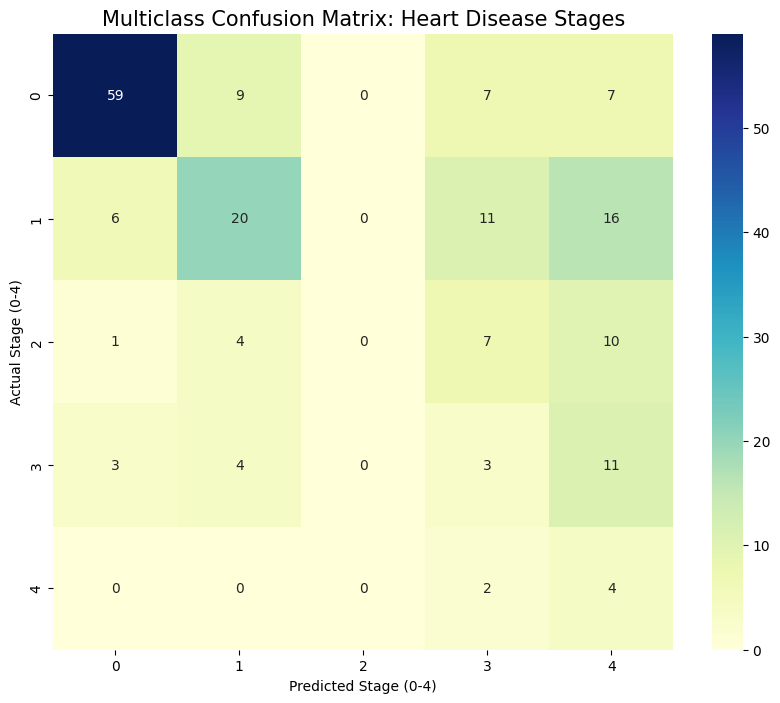

In [35]:
# "3. Model Evaluation:

#     Evaluate the model on the testing set using accuracy, precision, recall, and F1 score.
#     Use a confusion matrix to visualize the model’s performance."
y_pred = model.predict(X_test_scaled)
# Print the Classification Report
# This includes Precision, Recall, and F1-score for both classes
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

#Confusion Matrix:
# 1. Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# 2. Plotting the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True,          # Show the actual numbers in the boxes
    fmt='d',             # Format as integers
    cmap='YlGnBu',       # A clean color gradient
    xticklabels=[0, 1, 2, 3, 4], 
    yticklabels=[0, 1, 2, 3, 4]
)

plt.title('Multiclass Confusion Matrix: Heart Disease Stages', fontsize=15)
plt.xlabel('Predicted Stage (0-4)')
plt.ylabel('Actual Stage (0-4)')
plt.show()

Conclusion:
The results from testing this model are not very good (low accuracy, low precision and recall for most target values). This can be seen in the confusion matrix as well, with most cells being low.
This appears to be because the dataset is relatively small (920 rows before cleaning) and it may not be big enough to provide sufficient information to train a complex multiclass target model. With this size a dataset, it may be better to use a simpler binary model that can only predict whether or not there is heart disease, by converting the target value to binary (0 or 1) before training the model.